# Follow-up checks: what makes MedGemma say "yes" to an edit?

Four checks decided on 2026-09-30 (PLAN.md), run by `python -m cxr.dose followup`:
1. **Effusion dose-response.** The audit's lung-base mask at 5 depths (level 1.0 = the audit's
   edits), on the first 100 effusion source films. How much does each level change the aerated lung
   (segmenter) and the classifiers, and when does MedGemma switch to "yes"? Edits are compared with
   the blur control (no RadEdit) at the same measured lung loss.
2. **Cardiomegaly shams at low growth.** At growth 0 and 0.06 the feathered paste-back sits on the
   heart border. If shams (same mask, seed and path, normal prompt) also jump to "yes", the jump of
   the edits is a border artifact; if not, it comes from what the "Cardiomegaly" prompt paints.
3. **Heart intensity.** Mean gray-level change inside the original heart outline and on its border.
4. **Costophrenic angles.** Sharpness (mean gradient magnitude) at both angles, original vs image,
   for every effusion sham and addition, the blur control and the dose edits: do shams that flip
   lose more sharpness than shams that do not?

All films are one per patient, so resampling films resamples patients (95% bootstrap CIs).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent  # the notebook runs from notebooks/
sys.path.insert(0, str(ROOT))
from cxr.data import ACCENT, AXIS, GRID, INK, INK_2, MUTED, SURFACE

R = ROOT / "results"
models = ["4b", "1.5-4b"]
m1 = pd.read_csv(R / "dose_measures.csv")    # first dose run: effusion originals, blur, cardiomegaly edits
m2 = pd.read_csv(R / "dose2_measures.csv")   # follow-up: effusion dose edits, cardiomegaly shams
s1 = {m: pd.read_csv(R / f"dose_scores_{m}.csv") for m in models}
s2 = {m: pd.read_csv(R / f"dose2_scores_{m}.csv") for m in models}
audit = {m: pd.read_csv(R / f"audit_{m}_test.csv") for m in models}
thresholds = {m: pd.read_csv(R / f"audit_{m}_thresholds.csv") for m in models}
clf = pd.read_csv(R / "edit_classifiers.csv")
thr = {c: clf[(clf["classifier"] == c) & (clf["finding"] == "effusion")]["threshold"].item()
       for c in ["densenet121-res224-pc", "densenet121-res224-chex"]}
logit = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))

def ci_mean(x, n_boot=1000, seed=0):
    """95% bootstrap CI of a mean over films (one film per patient)."""
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    return np.percentile([x[rng.integers(len(x), size=len(x))].mean() for _ in range(n_boot)], [2.5, 97.5])

def ci_diff(a, b, n_boot=1000, seed=0):
    """95% bootstrap CI of mean(a) - mean(b), two independent groups of films."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    rng = np.random.default_rng(seed)
    return np.percentile([a[rng.integers(len(a), size=len(a))].mean() - b[rng.integers(len(b), size=len(b))].mean()
                          for _ in range(n_boot)], [2.5, 97.5])

print(m2.groupby(["group", "level"]).size().to_string())
print("Effusion classifier thresholds:", thr)

group          level
cardio_sham    0.00     100
               0.06     100
               0.30     100
effusion_dose  0.20     100
               0.40     100
               0.60     100
               0.80     100
               1.00     100
Effusion classifier thresholds: {'densenet121-res224-pc': 0.506, 'densenet121-res224-chex': 0.263}


## 1. Effusion dose-response

Lung-area change = aerated lung inside the audit's lung-base mask (the same region at every level),
relative to the original film. The addition check needs a loss of at least 10% and both classifiers
above their thresholds (the audit also required each score to rise; the originals' CheXpert scores
were not stored, so that part is left out here).

In [2]:
orig = m1[(m1["group"] == "original") & (m1["finding"] == "effusion")].set_index("image")
eff = pd.concat([m2[m2["group"] == "effusion_dose"], m1[m1["group"] == "blur"]], ignore_index=True)
eff["lung_area_change"] = eff["lung_area_in_mask"] / orig.loc[eff["image"], "lung_area_in_mask"].to_numpy() - 1
eff["pc_above"] = eff["classifier_effusion"] > thr["densenet121-res224-pc"]
eff["chex_above"] = eff["chex_effusion"] > thr["densenet121-res224-chex"]
eff["anatomy_ok"] = eff["lung_area_change"] <= -0.10
for m in models:
    scores = pd.concat([s2[m][s2[m]["group"] == "effusion_dose"], s1[m][s1[m]["group"] == "blur"]], ignore_index=True)
    first = scores[scores["phrasing"] == 0][["group", "image", "level", "p_yes"]].rename(columns={"p_yes": f"p_yes_{m}"})
    eff = eff.merge(first, on=["group", "image", "level"], how="left")
    base = s1[m][(s1[m]["group"] == "original") & (s1[m]["phrasing"] == 0)].set_index("image")["p_yes"]
    eff[f"d_log_odds_{m}"] = logit(eff[f"p_yes_{m}"]) - logit(base.loc[eff["image"]].to_numpy())

rows = []
for (group, level), g in eff.groupby(["group", "level"]):
    row = {"images": "RadEdit, level %.1f" % level if group == "effusion_dose" else "blur, sigma %g" % level, "n": len(g),
           "median_lung_area_change": g["lung_area_change"].median(), "share_loss_10pct": g["anatomy_ok"].mean(),
           "median_pc_effusion": g["classifier_effusion"].median(), "share_pc_above": g["pc_above"].mean()}
    if group == "effusion_dose":
        row.update({"median_chex_effusion": g["chex_effusion"].median(),
                    "share_both_classifiers_and_anatomy": (g["pc_above"] & g["chex_above"] & g["anatomy_ok"]).mean()})
    for m in models:
        row[f"median_p_yes_{m}"] = g[f"p_yes_{m}"].median()
        row[f"mean_d_log_odds_{m}"] = g[f"d_log_odds_{m}"].mean()
    rows.append(row)
effusion_dose = pd.DataFrame(rows).round(3)
effusion_dose.to_csv(R / "followup_effusion_dose.csv", index=False)
effusion_dose

,images,n,median_lung_area_change,share_loss_10pct,median_pc_effusion,share_pc_above,median_p_yes_4b,mean_d_log_odds_4b,median_p_yes_1.5-4b,mean_d_log_odds_1.5-4b,median_chex_effusion,share_both_classifiers_and_anatomy
0,"blur, sigma 3",100,-0.019,0.10,0.073,0.12,0.000,0.745,0.037,1.183,NaN,NaN
1,"blur, sigma 8",100,-0.241,0.76,0.434,0.44,0.000,6.230,0.904,6.077,NaN,NaN
2,"RadEdit, level 0.2",100,-0.026,0.00,0.128,0.26,0.546,12.584,1.000,10.287,0.082,0.00
3,"RadEdit, level 0.4",100,-0.044,0.08,0.520,0.59,1.000,21.409,1.000,15.293,0.123,0.02
4,"RadEdit, level 0.6",100,-0.061,0.30,0.622,0.75,1.000,23.549,1.000,16.259,0.193,0.09
5,"RadEdit, level 0.8",100,-0.078,0.42,0.727,0.81,1.000,24.198,1.000,16.444,0.285,0.22
6,"RadEdit, level 1.0",100,-0.092,0.47,0.842,0.85,1.000,24.578,1.000,16.456,0.492,0.29


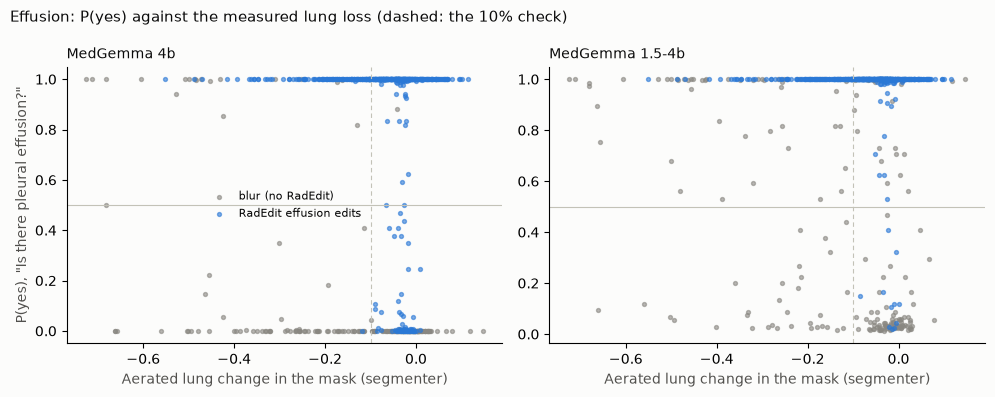

In [3]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), facecolor=SURFACE, squeeze=False)
for ax, m in zip(axes[0], models):
    for group, color, label in [("blur", MUTED, "blur (no RadEdit)"), ("effusion_dose", ACCENT, "RadEdit effusion edits")]:
        g = eff[eff["group"] == group]
        ax.scatter(g["lung_area_change"], g[f"p_yes_{m}"], s=8, color=color, alpha=0.6, label=label)
    ax.axvline(-0.10, color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.axhline(0.5, color=AXIS, linewidth=0.8)
    ax.set_xlabel("Aerated lung change in the mask (segmenter)", color=INK_2)
    ax.set_title(f"MedGemma {m}", loc="left", color=INK, fontsize=10)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylabel('P(yes), "Is there pleural effusion?"', color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Effusion: P(yes) against the measured lung loss (dashed: the 10% check)", x=0.01, ha="left",
             color=INK, fontsize=11)
fig.tight_layout()
fig.savefig(R / "followup_effusion_dose.png", dpi=200, facecolor=SURFACE)
plt.show()

RadEdit edits and blur at the same measured lung loss: mean P(yes) (first phrasing), edit minus blur.

In [4]:
bands = [-1.0, -0.30, -0.15, -0.05, 1.0]
rows = []
for m in models:
    e = eff.dropna(subset=[f"p_yes_{m}"]).copy()
    e["band"] = pd.cut(e["lung_area_change"], bands)
    for band, g in e.groupby("band", observed=True):
        a, b = g[g["group"] == "effusion_dose"][f"p_yes_{m}"], g[g["group"] == "blur"][f"p_yes_{m}"]
        if len(a) >= 5 and len(b) >= 5:
            lo, hi = ci_diff(a, b)
            rows.append({"model": m, "lung_change_band": str(band), "n_edits": len(a), "n_blur": len(b),
                         "mean_p_yes_edits": a.mean(), "mean_p_yes_blur": b.mean(),
                         "difference": a.mean() - b.mean(), "ci_low": lo, "ci_high": hi})
effusion_matched = pd.DataFrame(rows).round(3)
effusion_matched.to_csv(R / "followup_effusion_matched.csv", index=False)
effusion_matched

,model,lung_change_band,n_edits,n_blur,mean_p_yes_edits,mean_p_yes_blur,difference,ci_low,ci_high
0,4b,"(-1.0, -0.3]",15,40,1.000,0.376,0.624,0.470,0.759
1,4b,"(-0.3, -0.15]",58,32,1.000,0.101,0.899,0.780,0.992
2,4b,"(-0.15, -0.05]",163,34,0.945,0.126,0.819,0.712,0.918
3,4b,"(-0.05, 1.0]",264,94,0.797,0.031,0.766,0.705,0.823
4,1.5-4b,"(-1.0, -0.3]",15,40,1.000,0.732,0.268,0.155,0.375
5,1.5-4b,"(-0.3, -0.15]",58,32,1.000,0.450,0.550,0.413,0.685
6,1.5-4b,"(-0.15, -0.05]",163,34,0.993,0.523,0.470,0.337,0.622
7,1.5-4b,"(-0.05, 1.0]",264,94,0.959,0.265,0.695,0.614,0.765


## 2. Cardiomegaly: edits and shams at the same growth

Same films, masks and seeds; only the prompt differs ("Cardiomegaly" vs the normal prompt).
Growth 0.30 shams are the audit's shams.

In [5]:
rows = []
for growth in [0.0, 0.06, 0.30]:
    e = m1[(m1["group"] == "dose") & np.isclose(m1["level"], growth)].set_index("image")
    sh = m2[(m2["group"] == "cardio_sham") & np.isclose(m2["level"], growth)].set_index("image")
    row = {"growth": growth, "n": len(sh), "median_ctr_edit": e["ctr"].median(), "median_ctr_sham": sh["ctr"].median(),
           "median_classifier_edit": e["classifier_cardiomegaly"].median(),
           "median_classifier_sham": sh["classifier_cardiomegaly"].median()}
    for m in models:
        pe = s1[m][(s1[m]["group"] == "dose") & np.isclose(s1[m]["level"], growth) & (s1[m]["phrasing"] == 0)].set_index("image")["p_yes"]
        ps = s2[m][(s2[m]["group"] == "cardio_sham") & np.isclose(s2[m]["level"], growth) & (s2[m]["phrasing"] == 0)].set_index("image")["p_yes"]
        ps = ps.loc[pe.index]
        share_e, share_s = (pe > 0.5).astype(float), (ps > 0.5).astype(float)
        diff = logit(pe) - logit(ps)
        lo, hi = ci_mean(diff)
        row.update({f"share_yes_edit_{m}": share_e.mean(), f"share_yes_sham_{m}": share_s.mean(),
                    f"sham_ci_{m}": "%.2f-%.2f" % tuple(ci_mean(share_s)),
                    f"log_odds_edit_minus_sham_{m}": diff.mean(), f"lo_ci_{m}": "%.1f-%.1f" % (lo, hi)})
    rows.append(row)
cardio_shams = pd.DataFrame(rows).round(3)
cardio_shams.to_csv(R / "followup_cardio_shams.csv", index=False)
cardio_shams.T

,0,1,2
growth,0.0,0.06,0.3
n,100,100,100
median_ctr_edit,0.434,0.456,0.55
median_ctr_sham,0.422,0.429,0.436
median_classifier_edit,0.046,0.109,0.586
median_classifier_sham,0.029,0.028,0.05
share_yes_edit_4b,0.44,0.57,0.97
share_yes_sham_4b,0.14,0.16,0.31
sham_ci_4b,0.08-0.21,0.09-0.23,0.22-0.40
log_odds_edit_minus_sham_4b,5.517,8.427,16.205


## 3. Gray-level change inside the heart outline and on its border

In [6]:
h = pd.read_csv(R / "dose_heart_intensity.csv")
rows = []
for (kind, growth), g in h.groupby(["kind", "growth"]):
    lo, hi = ci_mean(g["change_in_heart"])
    blo, bhi = ci_mean(g["change_in_border_band"])
    rows.append({"kind": kind, "growth": growth, "n": len(g), "mean_change_in_heart": g["change_in_heart"].mean(),
                 "ci_heart": "%.1f to %.1f" % (lo, hi), "mean_change_on_border": g["change_in_border_band"].mean(),
                 "ci_border": "%.1f to %.1f" % (blo, bhi)})
heart = pd.DataFrame(rows).round(2)
heart.to_csv(R / "followup_heart_intensity.csv", index=False)
heart

,kind,growth,n,mean_change_in_heart,ci_heart,mean_change_on_border,ci_border
0,edit,0.00,100,12.33,11.2 to 13.5,5.48,5.1 to 5.9
1,edit,0.06,100,14.88,13.6 to 16.2,13.37,12.5 to 14.2
2,edit,0.12,100,16.80,15.4 to 18.3,19.34,18.1 to 20.6
3,edit,0.18,100,18.52,17.0 to 20.2,24.05,22.5 to 25.5
4,edit,0.24,100,19.87,18.2 to 21.6,27.79,26.1 to 29.4
5,edit,0.30,100,20.88,19.2 to 22.7,30.59,28.7 to 32.5
6,sham,0.00,100,-0.66,-2.6 to 1.3,0.45,-0.1 to 1.0
7,sham,0.06,100,-0.26,-2.4 to 1.8,1.40,0.4 to 2.5
8,sham,0.30,100,1.31,-1.2 to 3.9,4.07,2.1 to 6.2


## 4. Sharpness at the costophrenic angles

Sharpness loss = 1 - (sharpness after) / (sharpness before), both angles pooled. Shams are split by
the audit's primary flip rule (original below the Youden threshold; flip = sham above it).

In [7]:
cp = pd.read_csv(R / "costophrenic_sharpness.csv")
cp["loss"] = 1 - (cp["sharp_right_after"] + cp["sharp_left_after"]) / (cp["sharp_right_before"] + cp["sharp_left_before"])
print(cp.groupby(["kind", "level"], dropna=False)["loss"].agg(["size", "median", "mean"]).round(3).to_string())
shams = cp[cp["kind"] == "sham"].set_index("image")["loss"]
rows = []
for m in models:
    a = audit[m][audit[m]["finding"] == "effusion"]
    w = a.pivot_table(index=["image", "phrasing"], columns="variant", values="p_yes").reset_index()
    w = w.merge(thresholds[m][thresholds[m]["finding"] == "effusion"][["phrasing", "threshold"]])
    w = w[w["original"] < w["threshold"]]
    w["flip"] = w["sham"] > w["threshold"]
    w["loss"] = shams.loc[w["image"]].to_numpy()
    for phrasing, g in w.groupby("phrasing"):
        f, nf = g[g["flip"]]["loss"], g[~g["flip"]]["loss"]
        lo, hi = ci_diff(f, nf)
        rows.append({"model": m, "phrasing": phrasing, "n_flip": len(f), "n_no_flip": len(nf),
                     "mean_loss_flip": f.mean(), "mean_loss_no_flip": nf.mean(), "difference": f.mean() - nf.mean(),
                     "ci_low": lo, "ci_high": hi})
sharp_flip = pd.DataFrame(rows).round(3)
sharp_flip.to_csv(R / "followup_sharpness_flip.csv", index=False)
sharp_flip

                     size  median   mean
kind          level                     
blur          3.0     100   0.386  0.380
              8.0     100   0.597  0.577
edit          NaN     600   0.374  0.356
effusion_dose 0.2     100   0.360  0.338
              0.4     100   0.374  0.342
              0.6     100   0.376  0.348
              0.8     100   0.384  0.351
              1.0     100   0.384  0.357
sham          NaN     600   0.055  0.013


,model,phrasing,n_flip,n_no_flip,mean_loss_flip,mean_loss_no_flip,difference,ci_low,ci_high
0,4b,1,79,425,0.040,0.049,-0.009,-0.097,0.072
1,1.5-4b,0,75,444,0.054,0.041,0.013,-0.073,0.093
2,1.5-4b,1,76,447,0.008,0.040,-0.032,-0.159,0.074


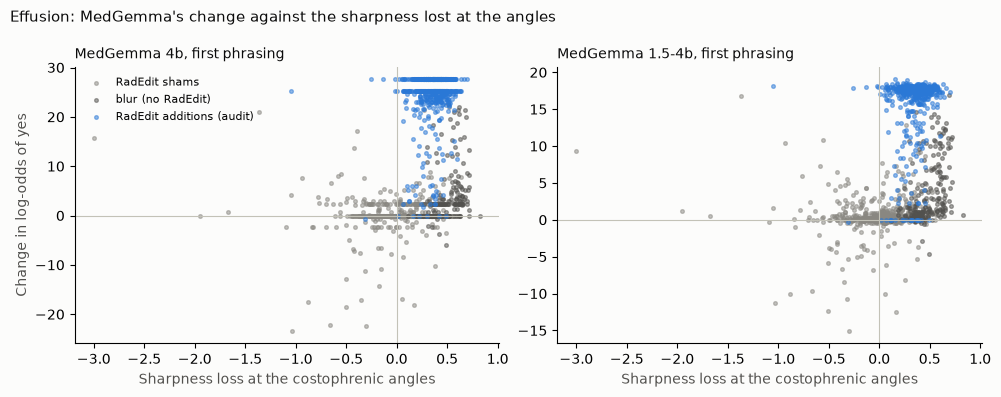

,model,images,n,spearman_loss_vs_d_log_odds
0,4b,sham,600,0.117
1,4b,blur,200,0.551
2,4b,edit,600,0.079
3,1.5-4b,sham,600,0.180
4,1.5-4b,blur,200,0.533
5,1.5-4b,edit,600,0.132


In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), facecolor=SURFACE, squeeze=False)
rows = []
for ax, m in zip(axes[0], models):
    a = audit[m][(audit[m]["finding"] == "effusion") & (audit[m]["phrasing"] == 0)]
    w = a.pivot_table(index="image", columns="variant", values="p_yes")
    groups = {"sham": logit(w["sham"]) - logit(w["original"]), "edit": logit(w["edit"]) - logit(w["original"])}
    g = eff[eff["group"] == "blur"]
    groups["blur"] = pd.Series(g[f"d_log_odds_{m}"].to_numpy(), index=pd.MultiIndex.from_arrays([g["image"], g["level"]]))
    for kind, color, label in [("sham", MUTED, "RadEdit shams"), ("blur", INK_2, "blur (no RadEdit)"),
                               ("edit", ACCENT, "RadEdit additions (audit)")]:
        c = cp[cp["kind"] == kind]
        y = groups[kind].loc[c["image"]].to_numpy() if kind != "blur" else groups[kind].loc[list(zip(c["image"], c["level"]))].to_numpy()
        ax.scatter(c["loss"], y, s=7, color=color, alpha=0.5, label=label)
        rows.append({"model": m, "images": kind, "n": len(c),
                     "spearman_loss_vs_d_log_odds": pd.Series(c["loss"].to_numpy()).corr(pd.Series(y), method="spearman")})
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.axvline(0, color=AXIS, linewidth=0.8)
    ax.set_xlabel("Sharpness loss at the costophrenic angles", color=INK_2)
    ax.set_title(f"MedGemma {m}, first phrasing", loc="left", color=INK, fontsize=10)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylabel("Change in log-odds of yes", color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Effusion: MedGemma's change against the sharpness lost at the angles", x=0.01, ha="left", color=INK, fontsize=11)
fig.tight_layout()
fig.savefig(R / "followup_sharpness.png", dpi=200, facecolor=SURFACE)
plt.show()
correlations = pd.DataFrame(rows).round(3)
correlations.to_csv(R / "followup_sharpness_correlation.csv", index=False)
correlations

## Takeaways

In [9]:
for _, r in effusion_dose.iterrows():
    print(f"{r['images']}: lung area {r['median_lung_area_change']:+.3f} (median), loss >= 10% in {r['share_loss_10pct']:.0%}; "
          f"median P(yes) 4B {r['median_p_yes_4b']:.3f}, 1.5 {r['median_p_yes_1.5-4b']:.3f}.")
for _, r in cardio_shams.iterrows():
    print(f"Cardiomegaly growth {r['growth']:.2f}: 'yes' (P > 0.5) on edits / shams: 4B {r['share_yes_edit_4b']:.0%} / "
          f"{r['share_yes_sham_4b']:.0%}, 1.5 {r['share_yes_edit_1.5-4b']:.0%} / {r['share_yes_sham_1.5-4b']:.0%}.")
for _, r in sharp_flip.iterrows():
    print(f"MedGemma {r['model']}, phrasing {r['phrasing']}: flipped shams lose {r['difference']:+.3f} more sharpness "
          f"(95% CI {r['ci_low']:+.3f} to {r['ci_high']:+.3f}; {r['n_flip']} vs {r['n_no_flip']} shams).")

blur, sigma 3: lung area -0.019 (median), loss >= 10% in 10%; median P(yes) 4B 0.000, 1.5 0.037.
blur, sigma 8: lung area -0.241 (median), loss >= 10% in 76%; median P(yes) 4B 0.000, 1.5 0.904.
RadEdit, level 0.2: lung area -0.026 (median), loss >= 10% in 0%; median P(yes) 4B 0.546, 1.5 1.000.
RadEdit, level 0.4: lung area -0.044 (median), loss >= 10% in 8%; median P(yes) 4B 1.000, 1.5 1.000.
RadEdit, level 0.6: lung area -0.061 (median), loss >= 10% in 30%; median P(yes) 4B 1.000, 1.5 1.000.
RadEdit, level 0.8: lung area -0.078 (median), loss >= 10% in 42%; median P(yes) 4B 1.000, 1.5 1.000.
RadEdit, level 1.0: lung area -0.092 (median), loss >= 10% in 47%; median P(yes) 4B 1.000, 1.5 1.000.
Cardiomegaly growth 0.00: 'yes' (P > 0.5) on edits / shams: 4B 44% / 14%, 1.5 58% / 31%.
Cardiomegaly growth 0.06: 'yes' (P > 0.5) on edits / shams: 4B 57% / 16%, 1.5 69% / 31%.
Cardiomegaly growth 0.30: 'yes' (P > 0.5) on edits / shams: 4B 97% / 31%, 1.5 99% / 39%.
MedGemma 4b, phrasing 1: flippe